# CA Cities Boundaries


### Step 0: Set-Up
Import the [climakitae](https://github.com/cal-adapt/climakitae) library and other dependencies.

In [1]:
import climakitae as ck

from climakitae.core.data_load import load

import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from climakitae.new_core.data_access.boundaries import Boundaries
import intake

### Step 1: Filter out offshore components from coastal cities

In [ ]:
boundaries_shp = gpd.read_file(
    "California_Cities_and_Identifiers_Blue_Version_view_-3024944392275494958.zip"
)

In [ ]:
boundaries_shp.shape

filter out offshore elements

In [ ]:
boundaries_shp_filtered = boundaries_shp[boundaries_shp['OFFSHORE'].isna()]

In [ ]:
boundaries_shp_filtered['OFFSHORE'].unique()

### Step 2: Convert boundaries shapefile to parquet

In [ ]:
boundaries_shp_filtered.to_parquet("CA_cities_boundaries_filtered.parquet")

### Step 3: Update new core boundaries file

In [36]:
catalog = intake.open_catalog('boundaries.yaml')
boundaries = Boundaries(catalog)
# Get all boundary options for UI population
boundary_options = boundaries.boundary_dict()

In [ ]:
# Access specific boundary data (loaded lazily)
ca_cities = boundaries._ca_cities
ca_counties= boundaries._ca_counties

In [ ]:
ca_counties[ca_counties["NAME"] == "Los Angeles County"]

In [ ]:
ca_counties["NAME"].duplicated().sum()

In [ ]:
ca_cities["CDT_NAME_S"].duplicated().sum()

In [ ]:
boundary_options['CA cities']

### Step 4: Test clip processor

In [9]:
catalog = intake.open_catalog("boundaries.yaml")
boundaries = Boundaries(catalog)
# Get all boundary options for UI population
boundary_options = boundaries.boundary_dict()

In [2]:
cd = ck.ClimateData()  # only give warnings and errors

2026-10-01 14:56:25 - climakitae.new_core.user_interface - INFO - Initializing ClimateData interface
2026-10-01 14:56:25 - climakitae.new_core.dataset_factory - INFO - DatasetFactory initialized with 4 validators and 12 processors
2026-10-01 14:56:25 - climakitae.new_core.user_interface - INFO - ClimateData initialization successful
2026-10-01 14:56:25 - climakitae.new_core.user_interface - INFO - ✅ Ready to query!


In [3]:
cd.show_boundary_options("CA cities")

2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Available CA cities Boundaries:
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - -------------------------------
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Showing 10 of 483 total boundaries, pass in `show_n`=None to see all boundaries.
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Adelanto
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Agoura Hills
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Alameda
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Albany
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Alhambra
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Aliso Viejo
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Alturas
2026-10-01 14:56:40 - climakitae.new_core.user_interface - INFO - Amador City
2026-10-01 14:56:40 - climakitae.new_core.user_inte

In [4]:
cd.show_variable_id_options()

whats going on?
how about this?
what about now?
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - Variables:
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - ----------
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - cape:                    Convective Available Potential Energy
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - cf:                      Capacity factor
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - cin:                     Convective Inhibition
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - dew_point:               No description available
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - effective_temp_index:    No description available
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - etrans_sfc:              Evapotranspiration
2026-10-01 14:56:46 - climakitae.new_core.user_interface - INFO - evap_sfc:                Evaporation
2026

2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Catalog set to: cadcat
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Activity ID set to: WRF
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Institution ID set to: UCLA
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Table ID set to: day
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Grid label set to: d03
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Variable ID set to: t2
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Processes set: 2 operations configured
2026-10-01 14:59:07 - climakitae.new_core.user_interface - INFO - Starting data retrieval with query: {'catalog': 'cadcat', 'installation': UNSET, 'activity_id': 'WRF', 'institution_id': 'UCLA', 'source_id': UNSET, 'experiment_id': UNSET, 'table_id': 'day', 'grid_label': 'd03', 'variable_id': 't2', 'station_id': UNSET, 'network_id': UNSET, 'processes': {'

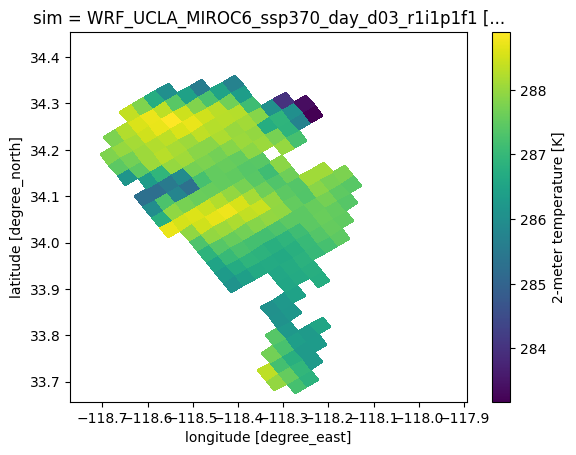

In [7]:
wl_clipped_data = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d03")
    .variable_id("t2")  # Temperature at 2 meters
    .processes(
        {
            "warming_level": {
                "warming_levels": [1.5, 2.0, 3.0],  # Warming levels in °C
            },
            "clip": "Los Angeles",  # Clip to specified coordinates
        }
    )
    .get()
)

wl_clipped_data

wl_clipped_data.isel(sim=0, warming_level=0, time_delta=0).t2.plot(x="lon", y="lat")

2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Catalog set to: cadcat
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Activity ID set to: WRF
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Institution ID set to: UCLA
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Table ID set to: day
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Grid label set to: d03
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Variable ID set to: t2
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Processes set: 2 operations configured
2026-10-01 14:57:52 - climakitae.new_core.user_interface - INFO - Starting data retrieval with query: {'catalog': 'cadcat', 'installation': UNSET, 'activity_id': 'WRF', 'institution_id': 'UCLA', 'source_id': UNSET, 'experiment_id': UNSET, 'table_id': 'day', 'grid_label': 'd03', 'variable_id': 't2', 'station_id': UNSET, 'network_id': UNSET, 'processes': {'

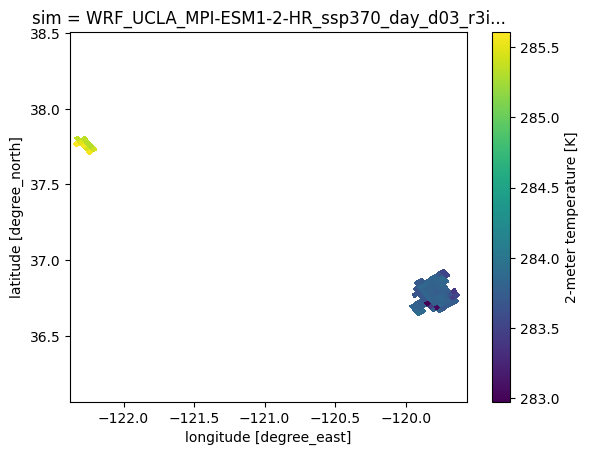

In [6]:
clip_counties = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d03")
    .variable_id("t2")  # Temperature at 2 meters
    .processes(
        {
            "warming_level": {
                "warming_levels": [1.5, 2.0, 3.0],  # Warming levels in °C
            },
            "clip": ["Alameda", "Fresno"],
        }
    )
    .get()
)

clip_counties.isel(sim=0, warming_level=0, time_delta=0).t2.plot(x="lon", y="lat")